# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli iML1515 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

This model is meant to be used with experimental data.

In [2]:
import os
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [3]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [4]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [5]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [6]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [7]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [ ]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

'\ndef plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):\n    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""\n    residuals = y_true - y_pred\n\n    fig, axs = plt.subplots(2, 2, figsize=(12, 10))\n\n    # True vs Predicted\n    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color=\'royalblue\')\n    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], \'k--\', lw=2)\n    axs[0, 0].set_title(f\'True vs Predicted: {label}\')\n    axs[0, 0].set_xlabel(\'True value\')\n    axs[0, 0].set_ylabel(\'Predicted\')\n    axs[0, 0].grid(True)\n\n    # Residuals plot\n    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color=\'darkorange\')\n    axs[0, 1].axhline(y=0, color=\'r\', linestyle=\'-\')\n    axs[0, 1].set_title(f\'Residuals: {label}\')\n    axs[0, 1].set_xlabel(\'True value\')\n    axs[0, 1].set_ylabel(\'Residuals\')\n    axs[0, 1].grid(True)\n\n    # Error distribution\n    sns.histplot

In [ ]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 16,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    pred_vals = []
    true_vals = []
    pos = None

    with torch.no_grad():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

'\ndef plot_flux(\n    model,\n    X_test,\n    y_test, \n    output_cols,\n    flux_name: str,\n    save_path=None,\n    batch_size=16,\n    device=\'cuda\' if torch.cuda.is_available() else \'cpu\'\n):\n    """\n    Plotting for a single flux column.\n    """\n\n    # find target column index\n    try:\n        target_idx = output_cols.index(flux_name) + 30\n    except ValueError:\n        raise ValueError(f"Flux \'{flux_name}\' not found in output_cols")\n\n    print(f"Plotting flux \'{flux_name}\' (column index {target_idx})")\n\n    model = model.to(device)\n    model.eval()\n\n    pred_vals = []\n    true_vals = []\n\n    with torch.no_grad():\n        for i in range(0, X_test.shape[0], batch_size):\n            xb = X_test[i:i+batch_size].to(device)  # [B, 2746]\n            yb_true = y_test[i:i+batch_size]\n\n            # c = [B, 2746, 1]\n            c = xb.unsqueeze(-1)\n\n            yb_pred = model(c)  # [B, 2746, 1]\n\n            # Slice only the flux we care\n          

### Load model

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
model_name = "iML1515_exp_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/iML1515_exp_d256_h8_l3_ff1024/iML1515_exp_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_exp_212000_samples.csv
Training samples: 169600
Test samples: 42400


### Load data

In [ ]:
# Load data using the same function as during training
set_seed()

#DATA_PATH = f"./data/2026-02-04_iML1515_exp_training_data_100000_samples.csv"

X, y, inputs, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
#X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()


Loaded data with 100000 samples from ./data/2026-02-04_iML1515_exp_training_data_100000_samples.csv
Extracted input columns count:  38
Extracted output columns count: 2712
Medium constraints are injected into these token indices (in outputs order):
[114, 1439, 288, 303, 206, 209, 106, 347, 112, 111, 99, 40, 45, 92, 104, 164, 304, 621, 700, 859, 913, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 1981, 86, 934, 2243, 2320, 108, 98, 1490, 217]
Training samples: 80000
Test samples: 20000


FluxTransformer(
  (input_embedding): Embedding(2712, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

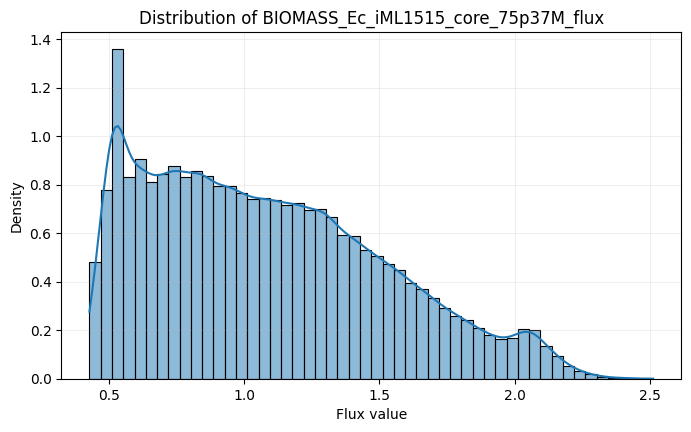

In [ ]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_core_75p37M_flux")

### Plot Results

In [13]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

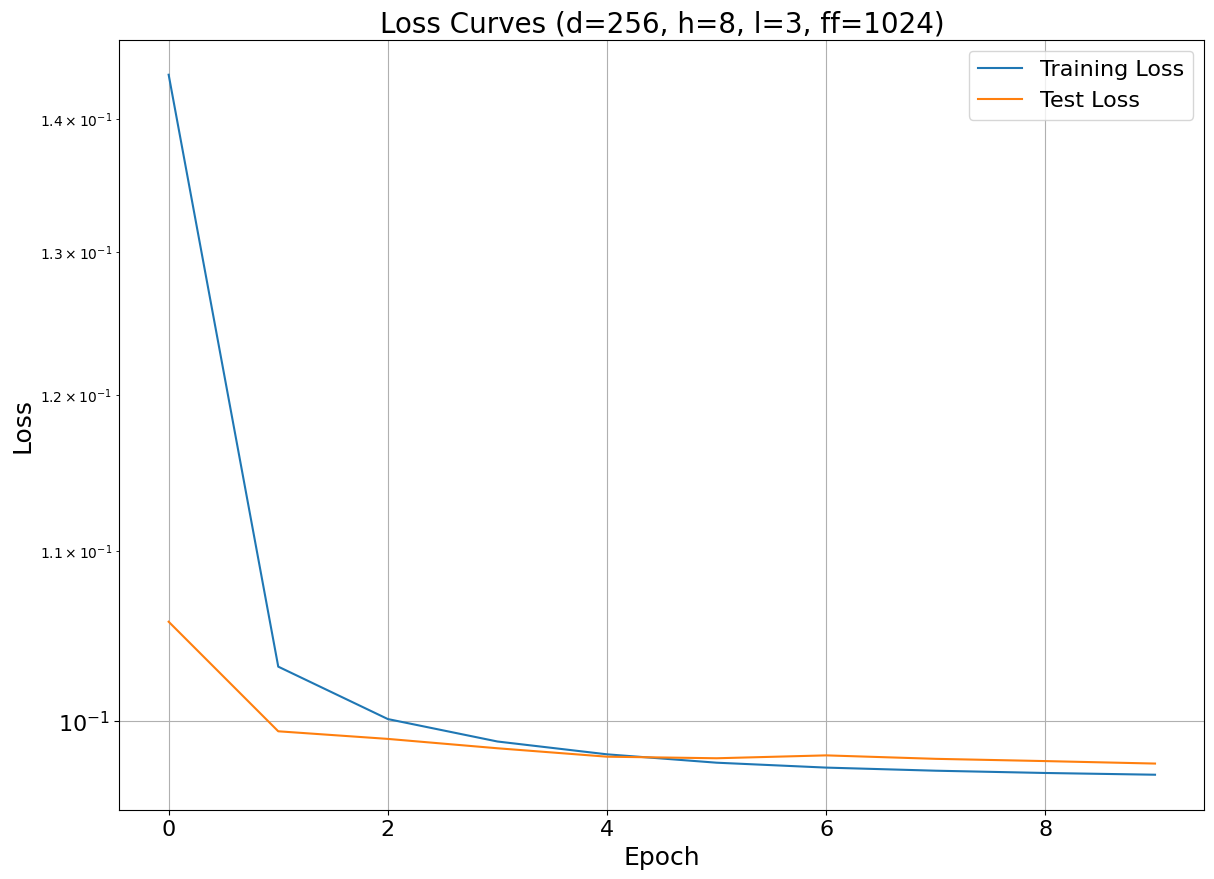

In [14]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_core_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_core_75p37M_flux token index: 2668
injected medium slot: False
y_true range: 0.4282186031341553 to 2.474637985229492
y_pred range: 0.4792081117630005 to 2.32145094871521


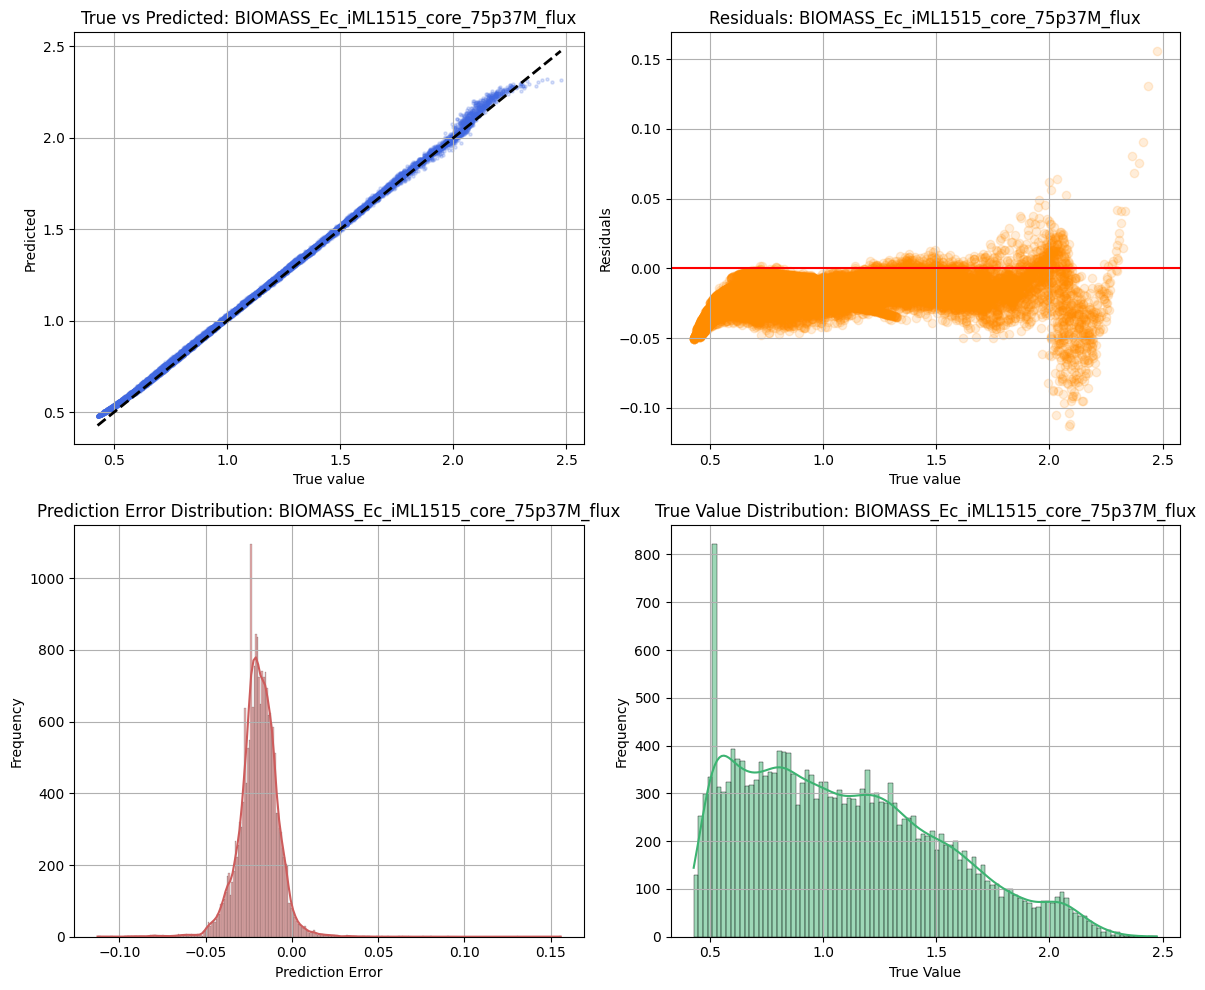

In [15]:
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_core_75p37M_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

ATPS4rpp_flux:
------------------------------------------------------------
ATPS4rpp_flux token index: 798
injected medium slot: False
y_true range: 43.80964279174805 to 164.03814697265625
y_pred range: 44.4427604675293 to 161.5423583984375


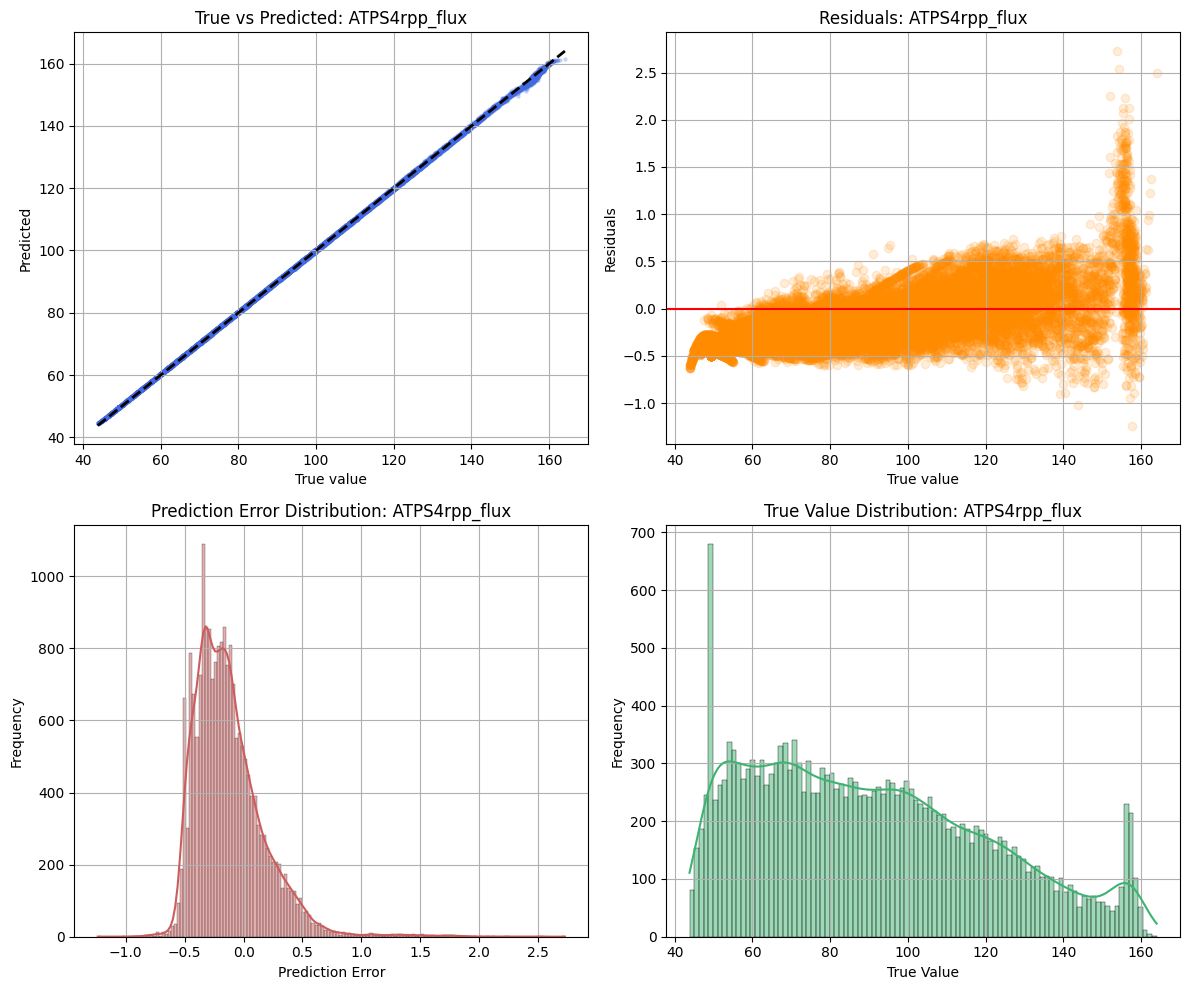

CYTBO3_4pp_flux:
------------------------------------------------------------
CYTBO3_4pp_flux token index: 1871
injected medium slot: False
y_true range: 28.6560001373291 to 99.99913787841797
y_pred range: 28.968130111694336 to 100.58842468261719


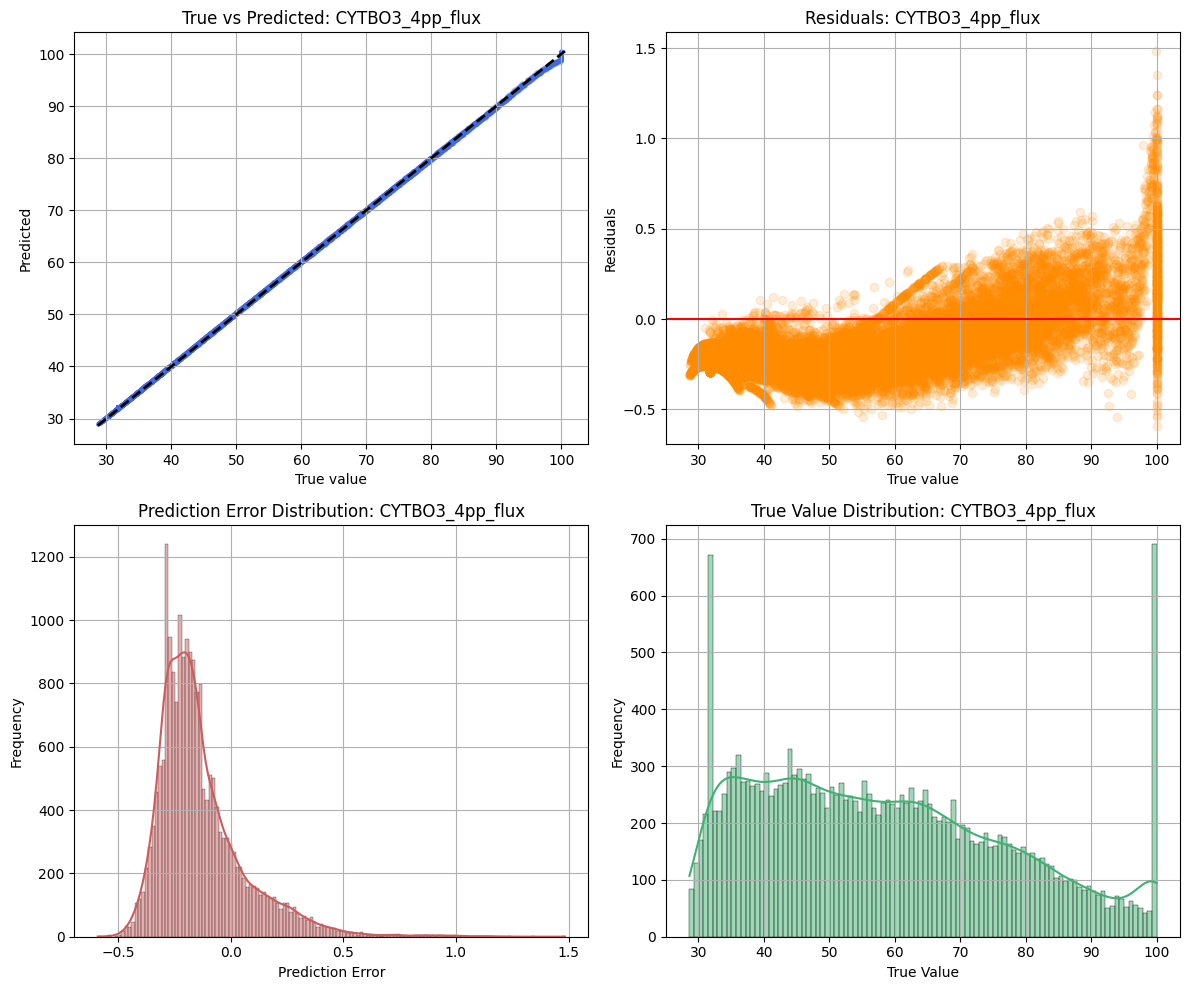

NADH16pp_flux:
------------------------------------------------------------
NADH16pp_flux token index: 2230
injected medium slot: False
y_true range: 0.0 to 94.8665542602539
y_pred range: 21.055618286132812 to 92.82904052734375


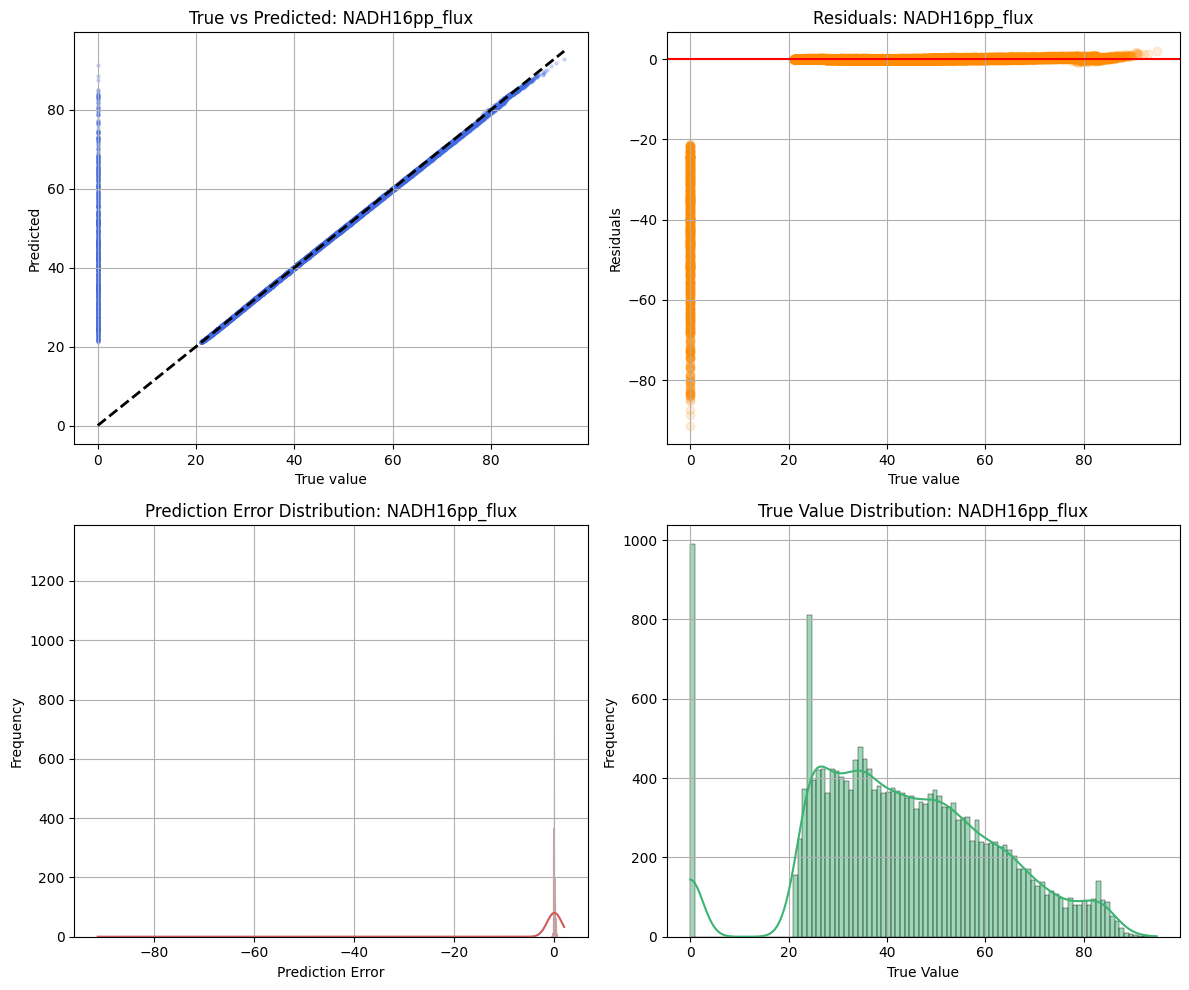

GAPD_flux:
------------------------------------------------------------
GAPD_flux token index: 601
injected medium slot: False
y_true range: -2.5299975872039795 to 51.393821716308594
y_pred range: -2.3308496475219727 to 48.97972869873047


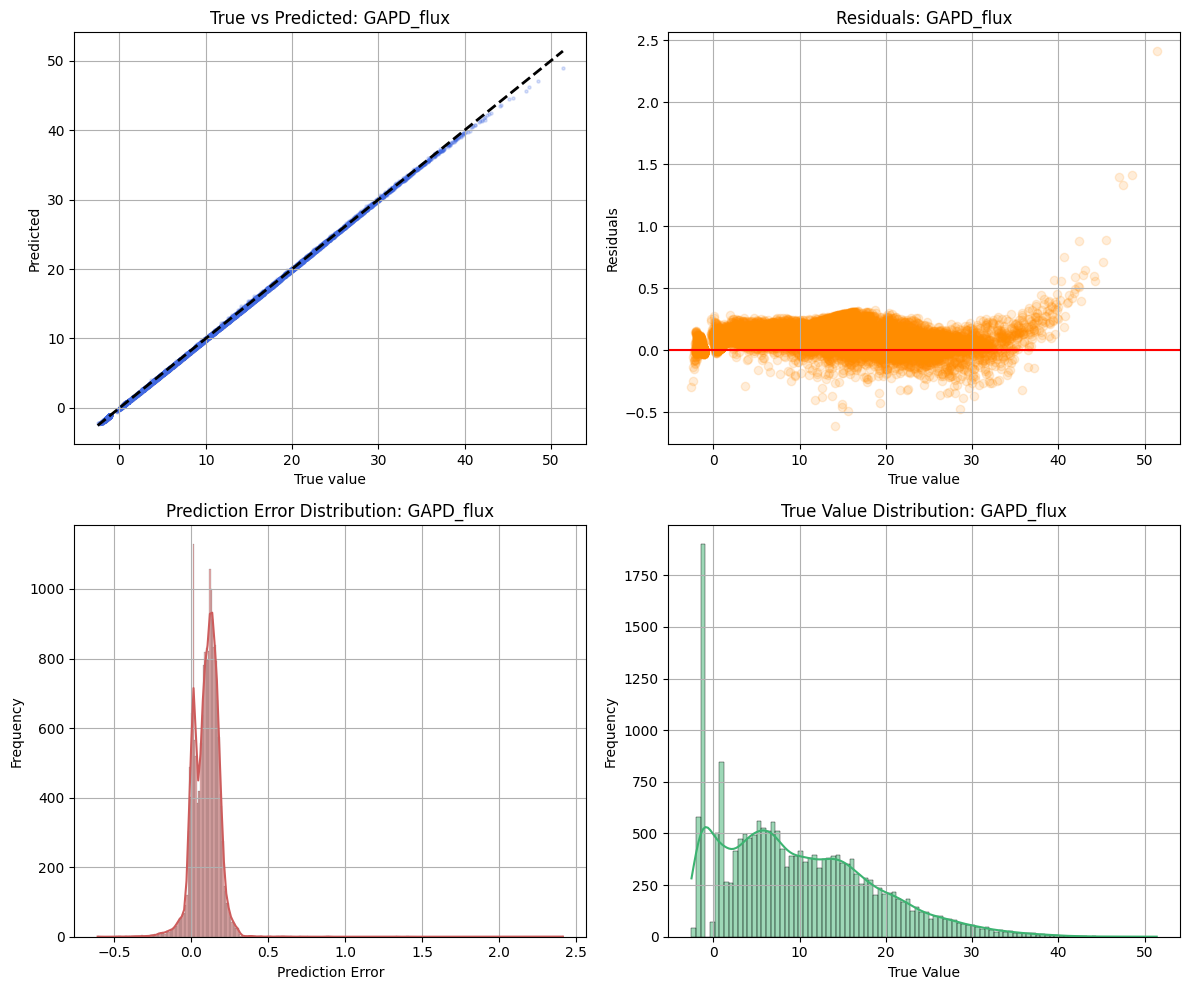

ENO_flux:
------------------------------------------------------------
ENO_flux token index: 126
injected medium slot: False
y_true range: -2.5299975872039795 to 48.66943359375
y_pred range: -2.7753233909606934 to 46.0601921081543


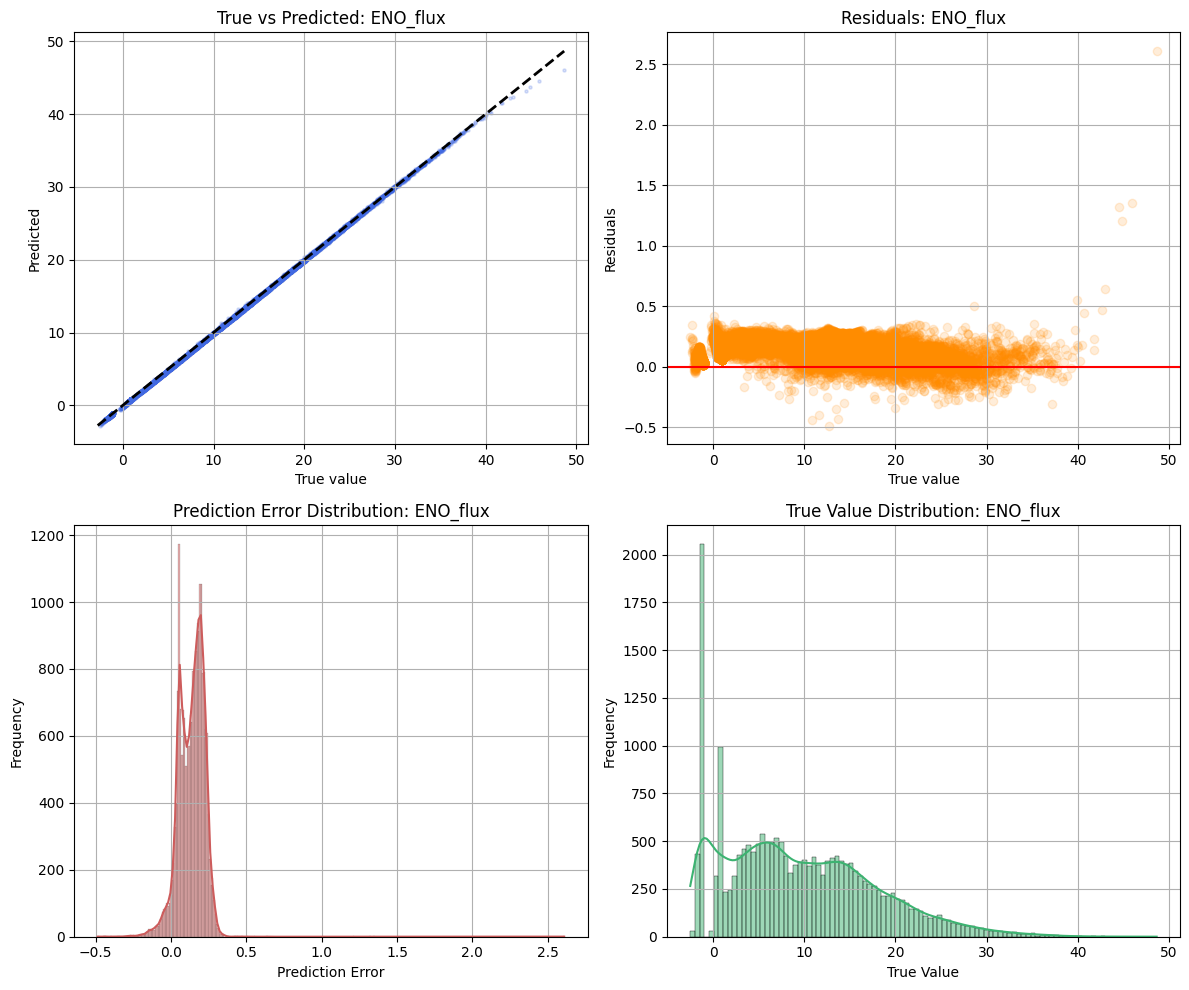

In [16]:
diagnostics_to_plot = ['ATPS4rpp_flux', 'CYTBO3_4pp_flux', 'NADH16pp_flux', 'GAPD_flux', 'ENO_flux', ]

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)